In [2]:
from __future__ import annotations
import os
import json
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatwCDM
import pandas as pd

import pymultinest
import matplotlib.pyplot as plt
import corner
from getdist import plots, MCSamples
import scipy.optimize as op
import astropy.units as u
from scipy import stats
import scipy.optimize as op


pc_to_cm = 3.08567758e18

In [108]:
LSdata_df = pd.read_csv('Compilation2026.csv',comment='#',index_col=False, dtype={'GEHR_id': str})
LS_tab = Table.from_pandas(LSdata_df)
LS_tab

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str11
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


### GEHR only

In [109]:
GEHR = LS_tab[(LS_tab['origin_id'] == 0.0)]

In [5]:
def GEHR_logL(mu,logF,e_mu,e_logF):
    d = (10**((mu+5)/5)) * pc_to_cm # cm
    F = 10 ** logF # erg s^-1 cm^-2
    L = 4 * np.pi * d**2 * F # erg s^-1
    logL = np.log10(L)
    e_PT = 4/25 * (e_mu**2) 
    e_ST = e_logF**2
    e_logL = np.sqrt(e_PT+e_ST)
    return logL,e_logL

In [6]:
LHb_GEHR = GEHR_logL(GEHR['z_or_mu'],GEHR['log_f_Hbeta'],GEHR['e_z_or_e_mu'],GEHR['e_log_f_Hbeta'])
sigma_GEHR = [GEHR['log_sigma'],GEHR['e_log_sigma']]

<ErrorbarContainer object of 3 artists>

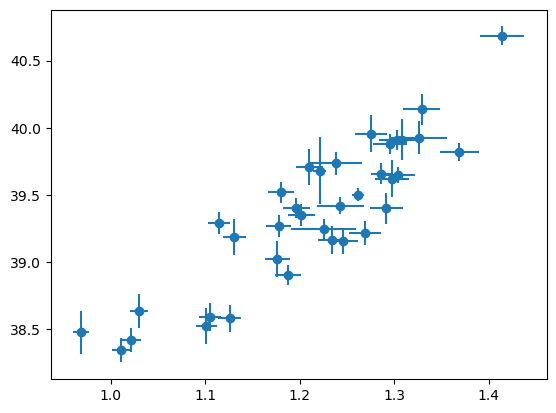

In [7]:
plt.errorbar(sigma_GEHR[0],LHb_GEHR[0],
             xerr=sigma_GEHR[1],yerr=LHb_GEHR[1],
             fmt='o')

In [8]:
def lnlike_GEHR(theta, logS, logF, muObs, e_logS, e_logF, e_muObs):
    alpha, beta = theta
    A = 2.5*(alpha + beta*logS) - (2.5*logF) + 100.19477738511641
    B = muObs
    C = 2.5 * np.sqrt((e_logS*beta)**2+(e_logF)**2)
    D = e_muObs
    U = (A-B)**2
    N = (C)**2 + (D)**2
    chi_sq = np.sum(U/N)
    ln_like = -1 * (1/2) * chi_sq
    return ln_like 

In [9]:
def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    return np.array([alpha, beta])

In [10]:
def nll(theta):
    return -lnlike_GEHR(theta, GEHR['log_sigma'], GEHR['log_f_Hbeta'], GEHR['z_or_mu'],
                         GEHR['e_log_sigma'], GEHR['e_log_f_Hbeta'], GEHR['e_z_or_e_mu'])

res = op.minimize(nll, 
                  x0=[32.0, 5.0], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [-46.9173138    5.02811421]


In [11]:
outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), "GEHR_only")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_GEHR(theta):
    return lnlike_GEHR(theta, GEHR['log_sigma'], GEHR['log_f_Hbeta'], GEHR['z_or_mu'],
                         GEHR['e_log_sigma'], GEHR['e_log_f_Hbeta'], GEHR['e_z_or_e_mu'])

In [12]:
n_dims = 2
result = pymultinest.solve(
    LogLikelihood=loglike_for_GEHR,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=1000,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    2
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        1.000000
Replacements:                               1050
Total Samples:                              1050
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999524
Acceptance Rate:                        0.997280
Replacements:                               1100
Total Samples:                              1103
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z): ************** +/-  0.999547
Acceptance Rate:                        0.993092
Replacements:                               1150


In [13]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))
samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -3178625.294 ± 0.165
Posterior means/stdev:
\alpha: 20.006 ± 0.000
 \beta: 9.997 ± 0.000
Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/GEHR_only


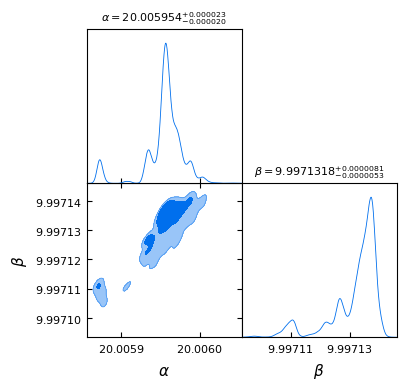

In [14]:
gds = MCSamples(
    samples=samples,
    names=["alpha", "beta"],
    labels=[r"\alpha", r"\beta"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

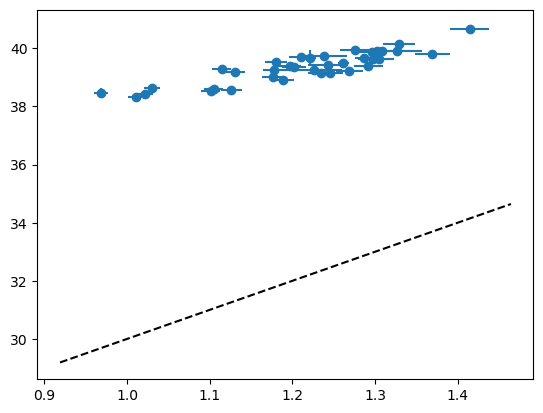

In [15]:
plt.errorbar(sigma_GEHR[0],LHb_GEHR[0],
             xerr=sigma_GEHR[1],yerr=LHb_GEHR[1],
             fmt='o')

x_line = np.linspace(sigma_GEHR[0].min()-0.05, sigma_GEHR[0].max()+0.05, 100)
y_line = 9.997 * x_line +  20.006

plt.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')

### Local_universe (Standard)

In [90]:
local_universe = LS_tab[(LS_tab['origin_id'] == 0.0) | ((LS_tab['origin_id'] != 0.0) & (LS_tab['z_or_mu'] <= 0.10))]

In [91]:
def lnlike_LU(theta,DF):
    alpha, beta, h0 = theta
    cosmo = FlatwCDM(H0=h0*100.0, Om0=0.3, w0=-1.0)

    G = local_universe['origin_id'] == 0.0
    H = local_universe['origin_id'] != 0.0


    Mum = DF['z_or_mu'] * 0.0
    MumErr = DF['e_z_or_e_mu'] * 0.0

    Mum[G] = DF[G]['z_or_mu']
    MumErr[G] = DF[G]['e_z_or_e_mu']
    Mum[H] = 5.0*np.log10(cosmo.luminosity_distance(DF[H]['z_or_mu']).value) + 25.0
    MumErr[H] = (5.0/np.log(10.0))*(DF[H]['e_z_or_e_mu']/DF[H]['z_or_mu'])

    Mu = 2.5*(beta*DF['log_sigma'] + alpha) - 2.5*DF['log_f_Hbeta'] - 100.19477738511641
    MuErr = 2.5*np.sqrt((DF['e_log_f_Hbeta'])**2 + beta**2*(DF['e_log_sigma'])**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2 * W)
    llq = -0.5*xsq
    return llq


In [92]:
def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    return np.array([alpha, beta, h0])

In [93]:
def nll(theta):
    return -lnlike_LU(theta,local_universe)

res = op.minimize(nll, x0=[32.0, 5.0, 0.75], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [33.2316836   5.03376931  0.72016568]


In [81]:
outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), "LocalUniverse")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_LU(theta):
    return lnlike_LU(theta,local_universe)

In [82]:
n_dims = 3
result = pymultinest.solve(
    LogLikelihood=loglike_for_LU,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=300,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  300
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.974930
Replacements:                                350
Total Samples:                               359
Nested Sampling ln(Z):            -628319.071376
Importance Nested Sampling ln(Z):    -358.867880 +/-  0.991302
Acceptance Rate:                        0.921659
Replacements:                                400
Total Samples:                               434
Nested Sampling ln(Z):            -189231.652210
Importance Nested Sampling ln(Z):    -359.057603 +/-  0.991545
Acceptance Rate:                        0.882353
Replacements:                                450


In [83]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -269.797 ± 0.185
Posterior means/stdev:
\alpha: 33.222 ± 0.157
 \beta: 5.042 ± 0.129
     h: 0.720 ± 0.044
Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/LocalUniverse


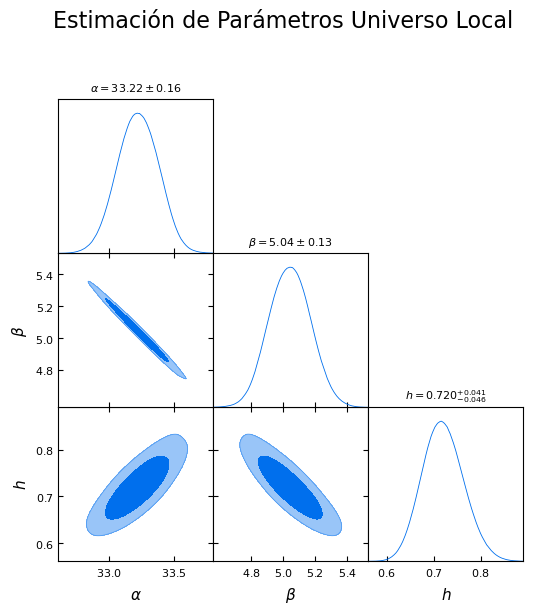

In [89]:

gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h"],
    labels=[r"\alpha", r"\beta", r"h"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.fig.suptitle("Estimación de Parámetros Universo Local", fontsize=16, y=1.03)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

In [110]:
GEHR = LS_tab[(LS_tab['origin_id'] == 0.0)]
GEHR

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str11
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


In [ ]:
def group_reader(DF, group):
    # 1. Convertir a pandas si viene como Astropy Table
    DF_pd = DF.to_pandas()
    df_group = pd.read_csv(group)
    # 2. Obtener la lista de galaxias únicas del grupo para el filtro principal
    galaxies_in_group = df_group['Galaxia'].unique()
    # 3. Aplicar tu filtro original
    filtro = DF_pd[DF_pd['GEHR_id'].isin(galaxies_in_group) | (DF_pd['origin_id'] > 0.0)].copy()
    # 4. Hacer un merge por izquierda para traer 'mu_w' y 'sigma_w' basados en la coincidencia de ID
    filtro = filtro.merge(
        df_group[['Galaxia', 'mu_w', 'sigma_w']], 
        left_on='GEHR_id', 
        right_on='Galaxia', 
        how='left'
    )
    # 5. Identificar las filas donde efectivamente hubo coincidencia (no son NaN)
    coincide = filtro['mu_w'].notna()
    # 6. Reemplazar los valores exclusivamente para las coincidencias
    filtro.loc[coincide, 'z_or_mu'] = filtro.loc[coincide, 'mu_w']
    filtro.loc[coincide, 'e_z_or_e_mu'] = filtro.loc[coincide, 'sigma_w']
    # 7. Limpiar las columnas auxiliares del merge para mantener el DF limpio
    filtro = filtro.drop(columns=['Galaxia', 'mu_w', 'sigma_w'])
    # 8. Regresar a Astropy Table
    new_DF = Table.from_pandas(filtro)
    return new_DF

group_reader(GEHR, group='t_r.csv')

index,z_or_mu,e_z_or_e_mu,log_sigma,e_log_sigma,log_f_Hbeta,e_log_f_Hbeta,origin_id,GEHR_id
int64,float64,float64,float64,float64,float64,float64,float64,str10
0,24.22,0.13,1.1803352,0.0136779,-10.2477404749,0.0576746197553,0.0,1.IC0010
1,24.22,0.13,1.1144041,0.0117835,-10.4759303122,0.0616196977511,0.0,1.IC0010
2,29.15,0.1,1.4143135,0.0233959,-11.0543846363,0.0571859387529,0.0,5.M101
3,29.15,0.1,1.3692392,0.0211037,-11.9205675872,0.0529003364017,0.0,5.M101
4,29.15,0.1,1.2958639,0.0178817,-11.8613707404,0.0609810126943,0.0,5.M101
5,29.15,0.1,1.3043677,0.0182209,-12.0887781044,0.0414250431862,0.0,5.M101
6,29.15,0.1,1.3026601,0.0181555,-11.8302225581,0.0592690973202,0.0,5.M101
7,24.58,0.1,1.1051128,0.0114869,-11.3192839883,0.0962665899784,0.0,3.M33
8,24.58,0.1,1.0106166,0.0093596,-11.5662672307,0.0815293027404,0.0,3.M33


In [ ]:
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

pc_to_cm = 3.08567758e18
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [ ]:
data = np.loadtxt("Union2020v16.dat")
idx        = data[:, 0].astype(int)
log_sigma  = data[:, 1]
log_fx     = data[:, 2]
z_or_mu    = data[:, 3]
err_logsig = data[:, 4]
err_logfx  = data[:, 5]
err_z_mu   = data[:, 6]
flag       = data[:, 7].astype(int)

In [ ]:
mask_mu = idx <= 36      # o (np.arange(len(idx)) < 36)
mask_z  = ~mask_mu
mask_hiiloc = (flag == 1)

In [ ]:
logL = np.zeros_like(log_fx)
err_logL = np.zeros_like(log_fx)

# GEHRs (primeros 36)
mu = z_or_mu[mask_mu]
logf_mu = log_fx[mask_mu]
err_logf_mu = err_logfx[mask_mu]
err_mu = err_z_mu[mask_mu]

# logL = logf + 0.4 * mu + 40.078
logL[mask_mu] = logf_mu + 0.4 * mu + 40.078

# errores
err_logL[mask_mu] = np.sqrt(err_logf_mu**2 + (0.4 * err_mu)**2)

In [ ]:
z = z_or_mu[mask_z]
logf_z = log_fx[mask_z]
err_logf_z = err_logfx[mask_z]
err_z = err_z_mu[mask_z]

# distancia de luminosidad
dL = cosmo.luminosity_distance(z)            # Mpc
dL_cm = dL.to(u.cm).value

logL[mask_z] = logf_z + 2*np.log10(dL_cm) + np.log10(4*np.pi)

# Propagación de errores en z (numérica)
logL_z = logL[mask_z].copy()
logL_z_plus = np.zeros_like(logL_z)

for i in range(len(z)):
    zp = z[i] + err_z[i]
    if zp <= 0:
        zp = z[i]  # por seguridad
    dL_p = cosmo.luminosity_distance(zp).to(u.cm).value
    logL_z_plus[i] = logf_z[i] + 2*np.log10(dL_p) + np.log10(4*np.pi)

sigma_logL_z = np.abs(logL_z_plus - logL_z)

err_logL[mask_z] = np.sqrt(err_logf_z**2 + sigma_logL_z**2)


In [ ]:
from scipy import stats

# ejemplo: sólo GEHRs + HIIG locales (flag 0 y 1)
mask_fit = (flag == 0) | (flag == 1)

x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=f"Fit: a={slope:.2f}, b={intercept:.2f}")
ax.legend()


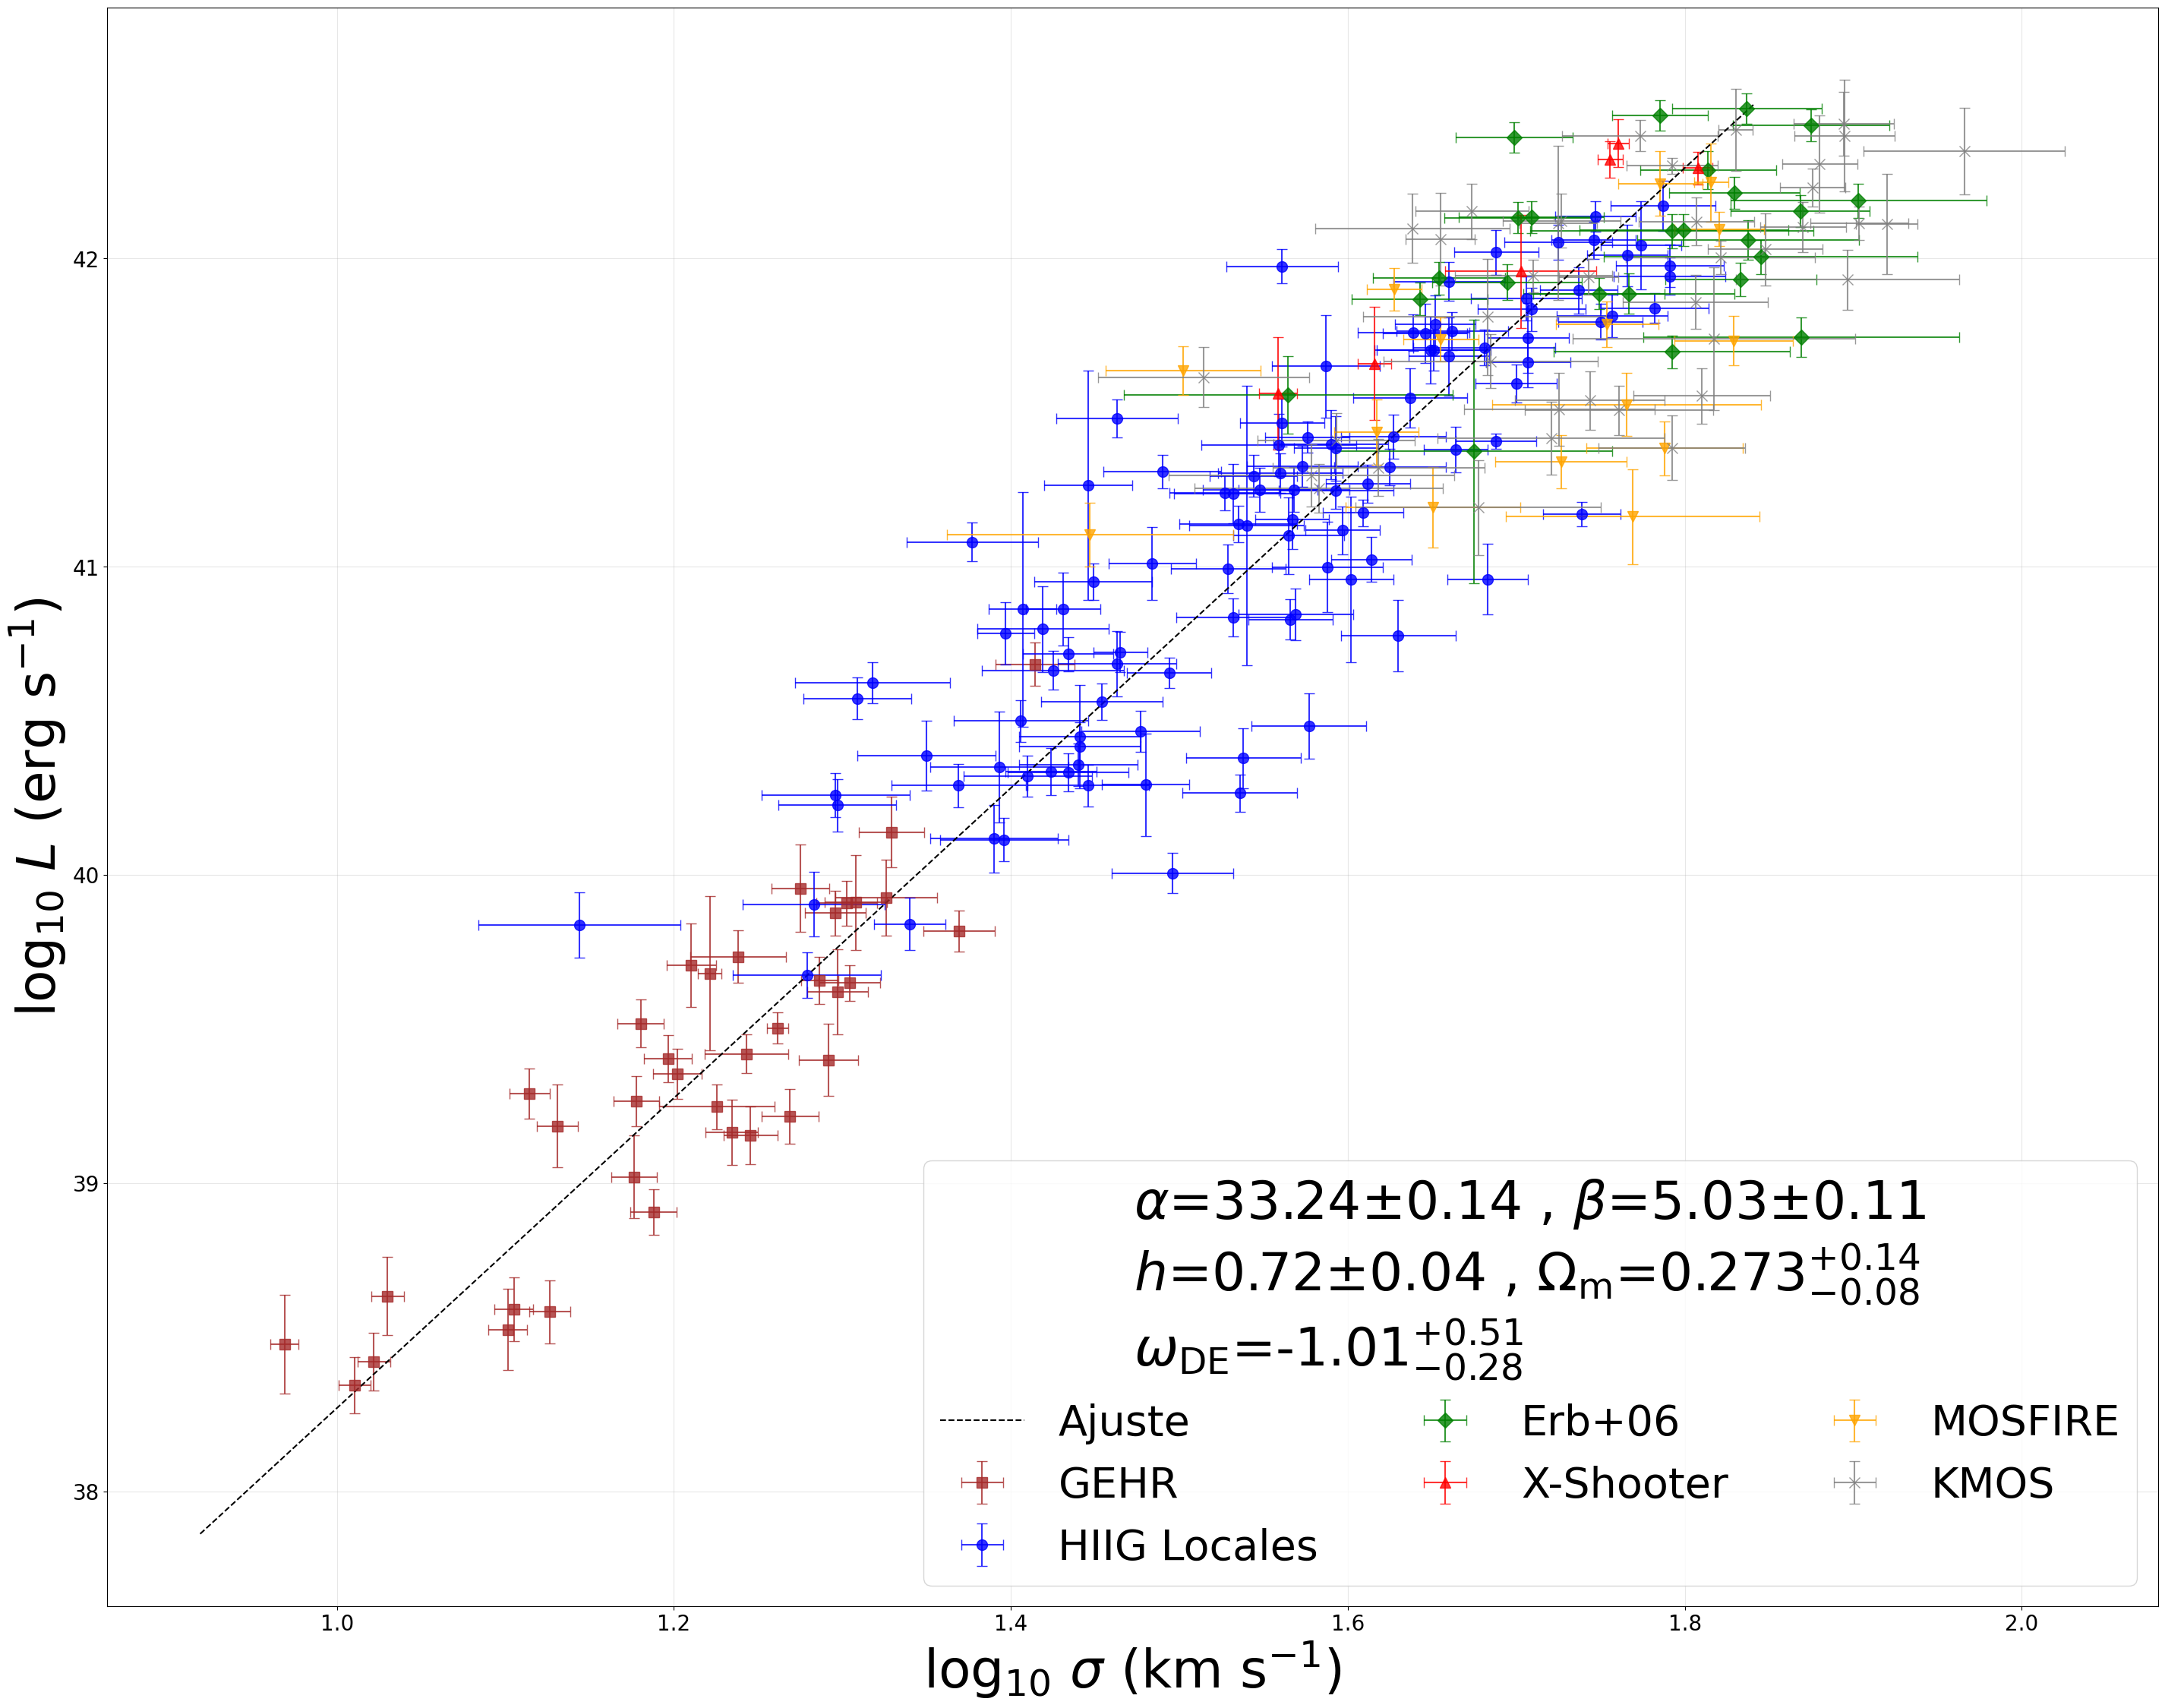

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(28.617329728, 22.592767987), dpi = 100)

samples = {
    0: "GEHR",
    1: "HIIG Locales",
    2: "Erb+06",
    3: "X-Shooter",
    4: "MOSFIRE",
    5: "KMOS",
}

markers = {0: "s", 1: "o", 2: "D", 3: "^", 4: "v", 5: "x"}
colors = {0: "brown", 1: "blue", 2: "green", 3: "red", 4: "orange", 5: "gray"}

for s, label in samples.items():
    m = flag == s
    if not np.any(m):
        continue
    ax.errorbar(
        log_sigma[m],
        logL[m],
        color = colors[s],
        xerr=err_logsig[m],
        yerr=err_logL[m],
        fmt=markers[s],
        linestyle="none",
        label=label,
        alpha=0.8,
        capsize=5,
        markersize=10
    )

ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 50)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 50)
ax.legend()
ax.grid(True, alpha=0.3)

#mask_fit = (flag == 0) | (flag == 1) | (flag == 2) | (flag == 3) | (flag == 4) | (flag == 5)
mask_fit = (flag == 0) | (flag == 1)


x = log_sigma[mask_fit]
y = logL[mask_fit]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

slope, intercept = 5.03 , 33.24 


# recta ajustada
x_line = np.linspace(x.min()-0.05, x.max()+0.05, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, label=r"Ajuste", color = 'k', linestyle = '--')


ax.tick_params(axis='x', labelsize=20) # Changes x-axis tick label font size
ax.tick_params(axis='y', labelsize=20) 


ax.legend(ncol= 3,
          title=r"$\alpha$=33.24$\pm$0.14 , "  + 
          r"$\beta$=5.03$\pm$0.11" + "\n" + 
          r"$h$=0.72$\pm$0.04 , "  + 
          r"$\Omega_\text{m}$=0.273$^{+0.14}_{-0.08}$" + "\n" + 
          r"$\omega_\text{DE}$=-1.01$^{+0.51}_{-0.28}$",
          title_fontsize=50,
          fontsize = 40)


plt.tight_layout()
plt.show()


## Implementacion para HIIGs (3 primeros parámetros)

## $$\alpha , \beta , H_0 $$

In [ ]:
from __future__ import annotations
import os
import json
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatwCDM

import pymultinest
import matplotlib.pyplot as plt
import corner
from getdist import plots, MCSamples
import scipy.optimize as op

In [45]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta
    Om = 0.3
    w0 = -1.0
    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)

    ixG = np.where(z > 10)
    ixH = np.where(z < 10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]
    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2 * W)
    llq = -0.5*xsq
    return llq 

In [46]:
def load_data(dpath):
    Tpath = os.path.join(dpath, 'Union2020v16.dat')
    data = Table.read(Tpath, format='ascii', comment='#')

    vix  = np.asarray(data['col1'])
    vx   = np.asarray(data['col2'])
    vy   = np.asarray(data['col3'])
    vz   = np.asarray(data['col4'])
    vxEr = np.asarray(data['col5'])
    vyEr = np.asarray(data['col6'])
    vzEr = np.asarray(data['col7'])
    vsp  = np.asarray(data['col8'])


    return vix, vx, vy, vz, vxEr, vyEr, vzEr, vsp

In [47]:

def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20->40
    beta  =  0.0 + 10.0 * u[1]     # 0->10
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    return np.array([alpha, beta, h0])

In [48]:
dpath = os.path.expanduser("~/HIIGalaxies/Bayesian_samplers/Multinest")

print("Data path:", dpath)

vTg, vx, vy, vz, vxErr, vyErr, vzErr, vsp = load_data(dpath)


Data path: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest


In [49]:

def nll(theta):
    return -lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

res = op.minimize(nll, x0=[32.0, 5.0, 0.75], method="Nelder-Mead")
print("ML guess:", res.x)

ML guess: [33.48268798  4.82632196  0.77453062]


In [50]:

outdir = os.path.join(dpath, "results_mnest")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_mnest(theta):
    return lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

In [51]:
n_dims = 3
result = pymultinest.solve(
    LogLikelihood=loglike_for_mnest,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=600,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  600
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.998464
Replacements:                                650
Total Samples:                               651
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -696.727189 +/-  0.999232
Acceptance Rate:                        0.990099
Replacements:                                700
Total Samples:                               707
Nested Sampling ln(Z):            -967846.796079
Importance Nested Sampling ln(Z):    -696.809710 +/-  0.999293
Acceptance Rate:                        0.979112
Replacements:                                750


In [52]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -447.450 ± 0.136
Posterior means/stdev:
\alpha: 33.484 ± 0.105
 \beta: 4.824 ± 0.085
     h: 0.778 ± 0.039


Corner guardado en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest/hii_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/results_mnest


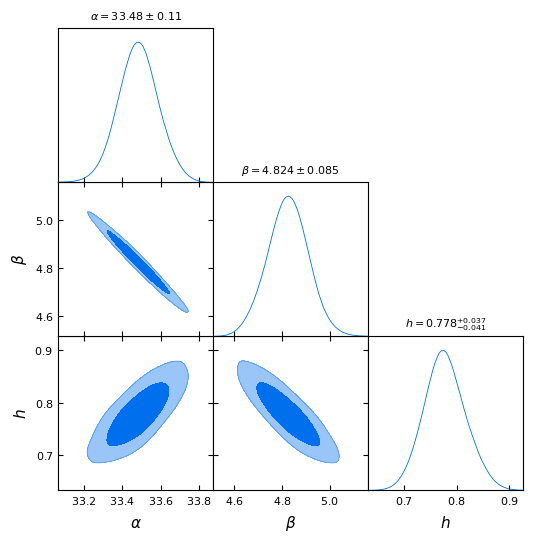

In [53]:

gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h"],
    labels=[r"\alpha", r"\beta", r"h"]  
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)

## Implementacion para HIIGs (5 parámetros)

## $$\alpha , \beta , H_0 , \Omega_{\text{m}} , w_{\text{DE}}$$

In [14]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, wDE = theta

    
    eps = 1e-6
    Om = np.clip(Om, eps, 1.0 - eps)
    h0 = float(h0)

    try:
        cosmo = FlatwCDM(H0=h0*100.0, Om0=Om, w0=wDE)
    except Exception:
        return -np.inf

    # índices
    ixG = (z >= 10)   
    ixH = (z <  10)

    Mum = np.zeros_like(z, dtype=float)
    MumErr = np.zeros_like(z, dtype=float)

    
    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

   
    zz = z[ixH]
    zzerr = zerr[ixH]
   
   
    if np.any(zz <= 0):
        return -np.inf

    try:
        DL = cosmo.luminosity_distance(zz).value  # Mpc
        if not np.all(np.isfinite(DL)) or np.any(DL <= 0):
            return -np.inf
        Mum[ixH] = 5.0*np.log10(DL) + 25.0
        MumErr[ixH] = (5.0/np.log(10.0))*(zzerr/zz)
    except Exception:
        return -np.inf

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt(yerr**2 + (beta**2)*(xerr**2))

    
    var = MuErr**2 + MumErr**2
    if np.any(var <= 0) or not np.all(np.isfinite(var)):
        return -np.inf

    R = Mu - Mum
    if not np.all(np.isfinite(R)):
        return -np.inf

    xsq = np.sum((R**2)/var)
    if not np.isfinite(xsq):
        return -np.inf

    return -0.5*xsq

In [15]:
def load_data(dpath):
    Tpath = os.path.join(dpath, 'indat/Union2020v16.dat')
    data = Table.read(Tpath, format='ascii', comment='#')

    vix  = np.asarray(data['col1'])
    vx   = np.asarray(data['col2'])
    vy   = np.asarray(data['col3'])
    vz   = np.asarray(data['col4'])
    vxEr = np.asarray(data['col5'])
    vyEr = np.asarray(data['col6'])
    vzEr = np.asarray(data['col7'])
    vsp  = np.asarray(data['col8'])

    LSL = 1.83
    ix = np.where((vx - vxEr) <= LSL)
    return vix[ix], vx[ix], vy[ix], vz[ix], vxEr[ix], vyEr[ix], vzEr[ix], vsp[ix]



In [16]:

def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 2->40
    beta  =  0.0 + 10.0 * u[1]     # 0->0
    h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
    Om    =  0.0 +  1.0 * u[3]
    wDE   = -2.0 +  3.0 * u[4]
    return np.array([alpha, beta, h0, Om, wDE])

In [17]:
HOME = os.path.expanduser("~") + '/HIIGs/'
dpath = os.path.join(HOME, "MCMC/ZEUS/h0wsh2023/dat/")

dpath = '/home/holman//MCMC/ZEUS/h0wsh2023/dat/'
print("Data path:", dpath)

vTg, vx, vy, vz, vxErr, vyErr, vzErr, vsp = load_data(dpath)

Data path: /home/holman//MCMC/ZEUS/h0wsh2023/dat/


In [18]:

outdir = os.path.join(dpath, "results_5nestHII")
os.makedirs(outdir, exist_ok=True)
prefix = os.path.join(outdir, "hii_")

def loglike_for_mnest(theta):
    return lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

In [19]:
n_dims = 5
result = pymultinest.solve(
    LogLikelihood=loglike_for_mnest,
    Prior=prior_transform,
    n_dims=n_dims,
    outputfiles_basename=prefix,
    evidence_tolerance=0.5,
    n_live_points=600,
    multimodal=True,
    verbose=True
)

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  600
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points


 live points generated, starting sampling
Acceptance Rate:                        0.993884
Replacements:                                650
Total Samples:                               654
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -473.077502 +/-  0.999235
Acceptance Rate:                        0.985915
Replacements:                                700
Total Samples:                               710
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -473.159659 +/-  0.999296
Acceptance Rate:                        0.975293
Replacements:                                750
Total Samples:                               769
Nested Sampling ln(Z):            -723935.410924
Importance Nested Sampling ln(Z):    -473.239485 +/-  0.999350
Acceptance Rate:                        0.963855
Replacements:                                800
Total Samples:                               830
Nested Sampling ln(Z):            

In [20]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))

samples = result["samples"]   # shape = (Nsamples, 5)
parameters = [r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")

# Guarda nombres para scripts auxiliares
with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)


fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$",r"\Omega_m",r"w_{DE}"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -407.389 ± 0.146
Posterior means/stdev:
\alpha: 33.231 ± 0.139
 \beta: 5.034 ± 0.114
     h: 0.718 ± 0.040
\Omega_m: 0.271 ± 0.112
w_{DE}: -0.997 ± 0.406
Corner guardado en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII/hii_corner.png


Removed no burn in
GetDist triangle en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII/hii_triangle_getdist.png

Listo. Archivos en: /home/holman//MCMC/ZEUS/h0wsh2023/dat/results_5nestHII


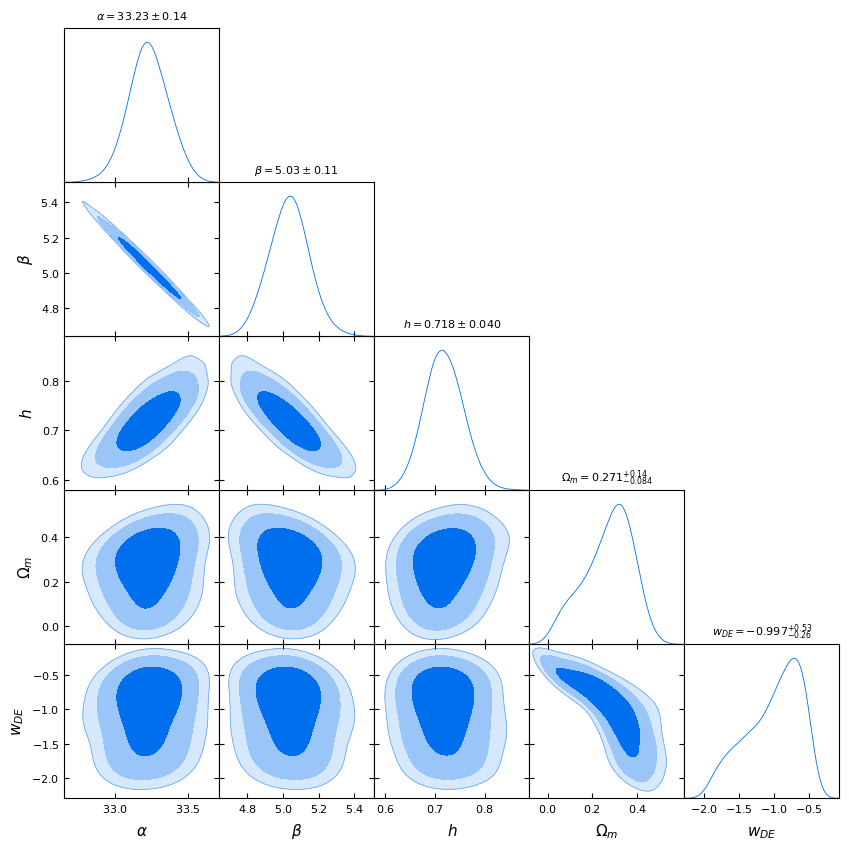

In [21]:
gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h","Om","wDE"],
    labels=[r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]  # SIN '$', GetDist los añade
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 3
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)